In [1]:
import torch
import numpy as np


In [ ]:
mu = []
cov = []
final_loss = []
sigma = []
theta_hat = []
run_nm = 5
for i in range(0, 5):
    mu_t = np.load(f"/pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/results/run{run_nm}/mu_t_NT25_NB25_chunk{i}_it{i*5}-{i*5+4}.npy")
    cov_t = np.load(f"/pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/results/run{run_nm}/cov_t_NT25_NB25_chunk{i}_it{i*5}-{i*5+4}.npy")  
    final_loss_t = np.load(f"/pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/results/run{run_nm}/final_loss_NT25_NB25_chunk{i}_it{i*5}-{i*5+4}.npy")    
    sigma_t = np.load(f"/pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/results/run{run_nm}/sigma_t_NT25_NB25_chunk{i}_it{i*5}-{i*5+4}.npy")
    theta_hat_t = np.load(f"/pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/results/run{run_nm}/theta_hat_NT25_NB25_chunk{i}_it{i*5}-{i*5+4}.npy")
    mu.extend(mu_t)
    cov.extend(cov_t)
    final_loss.extend(final_loss_t)
    sigma.extend(sigma_t)
    theta_hat.extend(theta_hat_t)


# test_run_nm = 1
# for i in range(0, 1):
#     mu_t = np.load(f"/pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/results/test_run{test_run_nm}/mu_t_NT1_NB1_chunk{i}_it{i*5}-{i}.npy")
#     cov_t = np.load(f"/pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/results/test_run{test_run_nm}/cov_t_NT1_NB1_chunk{i}_it{i*5}-{i}.npy")  
#     final_loss_t = np.load(f"/pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/results/test_run{test_run_nm}/final_loss_NT1_NB1_chunk{i}_it{i*5}-{i*5}.npy")    
#     sigma_t = np.load(f"/pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/results/test_run{test_run_nm}/sigma_t_NT1_NB1_chunk{i}_it{i*5}-{i*5}.npy")
#     theta_hat_t = np.load(f"/pscratch/sd/l/ljpuslar/RSA/RSA/src/Coverage_tests/results/test_run{test_run_nm}/theta_hat_NT1_NB1_chunk{i}_it{i*5}-{i*5}.npy")
#     mu.extend(mu_t)
#     cov.extend(cov_t)
#     final_loss.extend(final_loss_t)
#     sigma.extend(sigma_t)
#     theta_hat.extend(theta_hat_t)


mu = np.array(mu)
cov = np.array(cov)
final_loss = np.array(final_loss)
sigma = np.array(sigma)
theta_hat = np.array(theta_hat)


In [3]:
print("mu_t:", mu)
print(np.shape(mu))
print(np.shape(theta_hat))

mu_t: [[0.69179249 0.97979701]]
(1, 2)
(1, 1, 2)


In [4]:
print("mu_t:", mu_t)
print("cov_t:", cov_t)
print("final_loss:", final_loss)
print("sigma_t:", sigma_t)
print("theta_hat:", theta_hat)

mu_t: [[0.69179249 0.97979701]]
cov_t: [[0 0]]
final_loss: [[0.01642083]]
sigma_t: [[nan nan]]
theta_hat: [[[0.69179249 0.97979701]]]


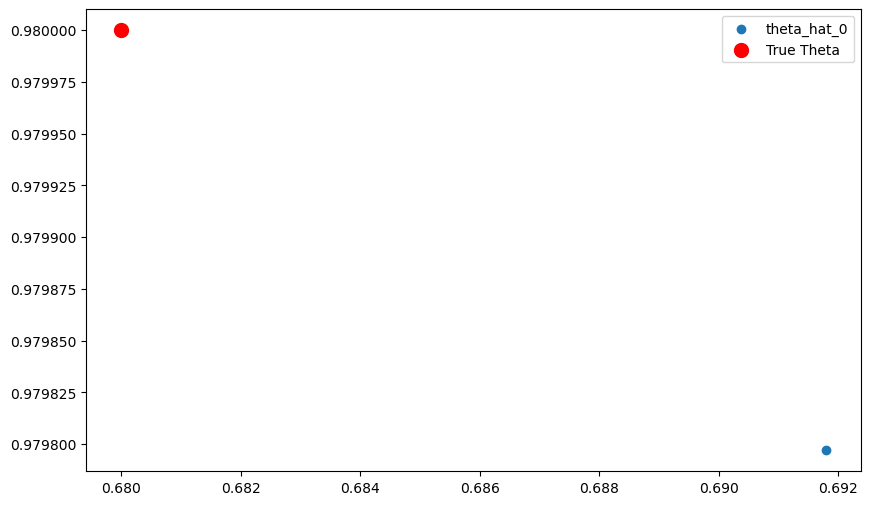

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for i in range(25):
    plt.scatter(theta_hat[i,:,0][theta_hat[i,:,0] > 0], theta_hat[i,:,1][theta_hat[i,:,0] > 0], label=f"theta_hat_{i}")
plt.scatter(0.68, 0.98, color='red', label='True Theta', marker='o', s=100)
plt.legend()
plt.show()

Data shape for ellipse (trajectory 0): (2, 25)
chi2_val: 2.27886856637673
vals: [2.20345433e-05 2.10298321e-06]
Data shape for ellipse (trajectory 1): (2, 25)
chi2_val: 2.27886856637673
vals: [1.97816868e-05 1.49155209e-06]
Data shape for ellipse (trajectory 2): (2, 25)
chi2_val: 2.27886856637673
vals: [3.10537856e-05 2.95535121e-06]
Data shape for ellipse (trajectory 3): (2, 25)
chi2_val: 2.27886856637673
vals: [4.2007763e-05 3.6092361e-06]
Data shape for ellipse (trajectory 4): (2, 25)
chi2_val: 2.27886856637673
vals: [1.42259537e-05 2.25908944e-06]
Data shape for ellipse (trajectory 5): (2, 25)
chi2_val: 2.27886856637673
vals: [3.72478091e-05 3.47353235e-06]
Data shape for ellipse (trajectory 6): (2, 25)
chi2_val: 2.27886856637673
vals: [2.71762469e-05 4.02238052e-06]
Data shape for ellipse (trajectory 7): (2, 25)
chi2_val: 2.27886856637673
vals: [4.72543663e-05 2.68298109e-06]
Data shape for ellipse (trajectory 8): (2, 25)
chi2_val: 2.27886856637673
vals: [4.74980109e-05 2.13491911

(0.62, 0.76)

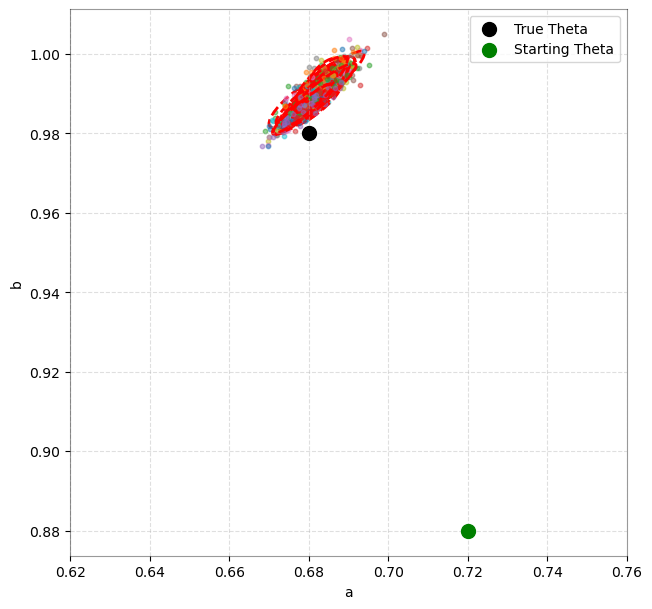

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(6, 6))

for i in range(len(theta_hat)):
    xs, ys = theta_hat[i,:,0][theta_hat[i,:,0] > 0], theta_hat[i,:,1][theta_hat[i,:,1] > 0]
    # xs, ys = theta_hat[i,:,0], theta_hat[i,:,1]
    # Confidence ellipse:
    data = theta_hat[i,:].T
    data = data[:, data[0] > 0]  # Filter out points where x <= 0
    print(f"Data shape for ellipse (trajectory {i}):", data.shape)
    # Covariance and mean
    cov = np.cov(data)
    mean = np.mean(data, axis=1)

    # Eigenvalues and eigenvectors
    vals, vecs = np.linalg.eigh(cov)

    # Sort by largest eigenvalue
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # 95% confidence level
    chi2_val = chi2.ppf(0.68, df=2)
    print("chi2_val:", chi2_val)
    print("vals:", vals)
    width, height = 2 * np.sqrt(vals * chi2_val)  # full lengths
    angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # Plot
    # fig, ax = plt.subplots()
    ax.scatter(xs, ys, s=10, alpha=0.5)
    # ax.scatter(xs, ys, s=10, alpha=0.5, label='Parameter fits')
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                    edgecolor='red', facecolor='none',linestyle='--', lw=2)
                    # edgecolor='red', facecolor='none',linestyle='--', lw=2, label='95% confidence ellipse')
    ax.add_patch(ellipse)

    ax.set_aspect('equal')

# Aesthetic tweaks
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
for spine in ax.spines.values():
    spine.set_alpha(0.4)
plt.scatter(0.68, 0.98, color='black', label='True Theta', marker='o', s=100, zorder=6)
plt.scatter(0.72, 0.88, color='green', label='Starting Theta', marker='o', s=100, zorder=6)
plt.tight_layout()
plt.legend()
plt.xlabel('a')
plt.ylabel('b')
plt.xlim([0.62,0.76])

In [8]:
import numpy as np
from scipy.stats import chi2

def point_in_confidence_ellipse(point, mean, cov, alpha=0.68, eps=1e-12):
    """
    point: (2,) array-like
    mean : (2,) array-like
    cov  : (2,2) covariance matrix
    alpha: confidence level (0.95 -> 95% ellipse)
    Returns: (inside: bool, d2: float, thresh: float)
    """
    point = np.asarray(point, dtype=float).reshape(2,)
    mean  = np.asarray(mean,  dtype=float).reshape(2,)
    cov   = np.asarray(cov,   dtype=float).reshape(2,2)

    # numerical safety: regularize if nearly singular
    cov_reg = cov + eps * np.eye(2)
    # cov_reg = cov

    delta = point - mean
    inv_cov = np.linalg.inv(cov_reg)
    d2 = float(delta.T @ inv_cov @ delta)

    thresh = float(chi2.ppf(alpha, df=2))
    return (d2 <= thresh), d2, thresh


In [9]:
true_theta = np.array([0.68, 0.98])
alpha = 0.68
cover_flags = []  # one per ellipse

for i in range(len(theta_hat)):
    data = theta_hat[i,:].T

    cov = np.cov(data)
    mean = np.mean(data, axis=1)

    inside, d2, thr = point_in_confidence_ellipse(true_theta, mean, cov, alpha=alpha)
    cover_flags.append(int(inside))
    print(f"i={i}: inside={inside}  d2={d2:.4f}  thr={thr:.4f}")

print(cover_flags)
print("Coverage:", np.mean(cover_flags))

i=0: inside=False  d2=19.0985  thr=2.2789
i=1: inside=False  d2=36.2682  thr=2.2789
i=2: inside=False  d2=20.5800  thr=2.2789
i=3: inside=False  d2=15.9441  thr=2.2789
i=4: inside=False  d2=16.4643  thr=2.2789
i=5: inside=False  d2=14.4634  thr=2.2789
i=6: inside=False  d2=16.6493  thr=2.2789
i=7: inside=False  d2=15.3984  thr=2.2789
i=8: inside=False  d2=14.0477  thr=2.2789
i=9: inside=False  d2=10.1324  thr=2.2789
i=10: inside=False  d2=34.2520  thr=2.2789
i=11: inside=False  d2=12.6336  thr=2.2789
i=12: inside=False  d2=21.5082  thr=2.2789
i=13: inside=False  d2=12.3087  thr=2.2789
i=14: inside=False  d2=18.1002  thr=2.2789
i=15: inside=False  d2=27.5634  thr=2.2789
i=16: inside=False  d2=16.1798  thr=2.2789
i=17: inside=False  d2=14.0308  thr=2.2789
i=18: inside=False  d2=11.5512  thr=2.2789
i=19: inside=False  d2=22.9345  thr=2.2789
i=20: inside=False  d2=20.0014  thr=2.2789
i=21: inside=False  d2=25.2420  thr=2.2789
i=22: inside=False  d2=25.4890  thr=2.2789
i=23: inside=False  d

In [10]:
print(cover_flags)
print("Coverage:", np.mean(cover_flags))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Coverage: 0.0
